# 02 — Instrument/source comparison

> **Synthetic demonstration.** The controlled offset in this notebook was
> generated by `scripts/generate_sample_data.py`; it is not a historical result.

The comparison uses QC-passing observations at exact common
timestamps. It does not interpolate, select a preferred instrument, or apply a
calibration correction.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

ROOT = next(
    candidate
    for candidate in [Path.cwd(), *Path.cwd().parents]
    if (candidate / "src" / "weather_pipeline").exists()
)
sys.path.insert(0, str(ROOT / "src"))
SAMPLE = ROOT / "data" / "sample"
FIGURES = ROOT / "figures"
FIGURES.mkdir(exist_ok=True)
plt.style.use("seaborn-v0_8-whitegrid")


In [2]:
from weather_pipeline import (
    apply_quality_flags,
    compare_instruments,
    concatenate_sources,
    load_campbell_csv,
    load_davis_30min_csv,
)

left_source = "synthetic_campbell_hourly"
right_source = "synthetic_davis_30min"
campbell = load_campbell_csv(
    SAMPLE / "synthetic_campbell_hourly.csv",
    source=left_source,
    instrument="Synthetic Campbell-like source",
)
davis = load_davis_30min_csv(
    SAMPLE / "synthetic_davis_30min.csv",
    source=right_source,
    instrument="Synthetic Davis-like source",
)
observations = apply_quality_flags(concatenate_sources([campbell, davis]))
aligned, metrics = compare_instruments(observations, left_source, right_source)
display(pd.Series(metrics, name="value").to_frame())

,value
left_source,synthetic_campbell_hourly
right_source,synthetic_davis_30min
paired_observations,2154
overlap_start,2017-04-17T12:00:00
overlap_end,2017-07-16T11:00:00
mean_difference_c,-1.250102
median_difference_c,-1.25
mae_c,1.250102
rmse_c,1.251329
correlation,0.999746


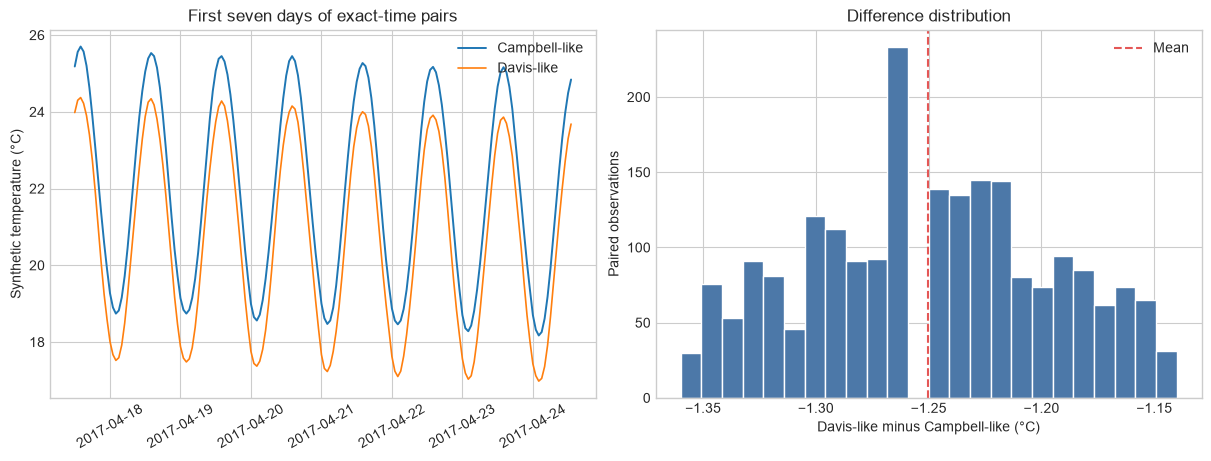

WindowsPath('figures/demo_instrument_comparison.png')

In [3]:
difference_column = f"{right_source}_minus_{left_source}_c"
window = aligned.head(24 * 7)

fig, (series_axis, difference_axis) = plt.subplots(
    1, 2, figsize=(12, 4.5), constrained_layout=True
)
series_axis.plot(window["timestamp"], window[left_source], label="Campbell-like", linewidth=1.4)
series_axis.plot(window["timestamp"], window[right_source], label="Davis-like", linewidth=1.2)
series_axis.set_title("First seven days of exact-time pairs")
series_axis.set_ylabel("Synthetic temperature (°C)")
series_axis.tick_params(axis="x", rotation=30)
series_axis.legend()

difference_axis.hist(aligned[difference_column], bins=24, color="#4C78A8", edgecolor="white")
difference_axis.axvline(metrics["mean_difference_c"], color="#E45756", linestyle="--", label="Mean")
difference_axis.set_title("Difference distribution")
difference_axis.set_xlabel("Davis-like minus Campbell-like (°C)")
difference_axis.set_ylabel("Paired observations")
difference_axis.legend()

output = FIGURES / "demo_instrument_comparison.png"
fig.savefig(output, dpi=160, bbox_inches="tight")
plt.show()
output.relative_to(ROOT)

## Interpretation boundary

The synthetic series agree strongly because they were generated from the same
signal with a controlled offset. In the recovered archive, an observed offset
may combine instrument response, siting, exposure, timestamp semantics, and
processing history. Without those metadata, the defensible language is
**difference between sources during overlap**, not bias or calibration error.